(monotonic-ray)=

# 单调平滑插值

单调平滑插值，目的是：给定一组数据$(x,y)$，建立一个全局上函数单调的插值函数。因此它分为两步，一个步骤是平滑，一个步骤是插值。平滑使得数据单调，然后再使用保单调的插值函数进行插值。


## 单调插值
给定一组数据 $(x,y)$, `Gal3D` 应用了 [PCHIP 插值器](https://doi.org/10.1137/0905021) 的插值方法。该方法不仅能够提供高质量的插值结果，还能保持数据的单调性和局部形状特征。



假设给定数据点 $x_1<x_2< \cdots <x_n (n \geq 2)$, 以及对应的 $y_i = f(x_i), i=1,\dots,n$

需要确定插值函数的形式为：

$$
f_i(x) = a_i(x - x_i)^3 + b_i(x - x_i)^2 + c_i(x - x_i) + d_i
$$


其中，定义变量 $ \Delta x_i = x_{i+1} - x_i $ ; $ \Delta y_i = y_{i+1} - y_i $ ; 斜率则为 $ \Delta _i = \Delta y_i/\Delta x_i$

**确定每个节点处的导数**

对于端点 $x_1$ 和 $x_n$: 
如果只有两个节点$(n = 2)$, 直接设置导数为斜率： $ f_{1}^{'} = \Delta _1, f_{2}^{'} = \Delta _1 $ 

如果节点数 $n > 2$，使用 Fritsch-Butland 方法计算：

左侧端点的预期导数 为 $G_1 = [(2\Delta x_1 + \Delta x_2)\Delta _1 - \Delta x_1 \Delta _2]/(\Delta x_1 + \Delta x_2)$，实际为：

$$ f_{1}^{'} = 
\begin{cases}
0  &  G_1 \cdot \Delta_1 \leq 0, \\
3\Delta_1   &  \Delta_1 \cdot \Delta_2 < 0 \text{ and } |G_1| > 3|\Delta_1|, \\
G_1  & \text{otherwise.} \\
\end{cases} $$

右侧端点的预期导数为：$G_n = [(2\Delta x_{n-1} + \Delta x_{n-2})\Delta _{n-1} - \Delta x_{n-1} \Delta _{n-2}]/(\Delta x_{n-1} + \Delta x_{n-2})$，实际为：

$$ f_{n}^{'} = 
\begin{cases} 0  &  G_n \cdot \Delta_{n-1} \leq 0, \\
3\Delta_{n-1}   &  \Delta_{n-1} \cdot \Delta_{n-2} < 0 \text{ and } |G_n| > 3|\Delta_{n-1}|, \\ G_n  & \text{otherwise.}\\ \end{cases}$$

对于内部节点 $x_k$ 处的预期导数为：$G_k =\Delta_k \Delta_{k-1} \frac{W_1 + W_2}{W_1 \Delta_k+ W_2 \Delta_{k-1}}$，其中 $W_1 = 2\Delta x_k + \Delta x_{k-1}, \quad W_2 = \Delta x_k + 2\Delta x_{k-1}$，实际为：

$$f_{k}^{'} = \begin{cases} 0  & \Delta_{k} \cdot \Delta_{k-1} \leq 0, \\G_k  & \text{otherwise.}\\ \end{cases}$$


**计算插值函数的系数**

在得到 $f_{i}^{'}, f_{i+1}^{'}$ 后，插值函数的系数计算如下：
   - 常数项系数：

$$d_i = y_i$$

   - 一次项系数：

$$c_i = f_{i}^{'}$$

   - 二次项系数：

$$b_i = \frac{3\Delta_i - 2f_{i}^{'} - f_{i+1}^{'}}{\Delta x_i}$$

   - 三次项系数：

$$a_i = \frac{f_{i}^{'} + f_{i+1}^{'} - 2 \Delta_i}{\Delta x_i \Delta x_i}$$

## 单调平滑

对于给定数据$(x,y)$，若 $x$ 是单调递增的，则可以直接进行 PCHIP 插值。然而，在某些情况下，插值函数需要满足全局单调性，而不仅仅是局部区间的单调性。这种需求通常源于模型或理论的约束。然而，实际数据可能由于噪声等原因不满足单调性，因此需要对 $y$ 进行平滑处理，使其单调后再进行插值。

具体步骤如下：
1. 确定单调边界
    首先，对数据 $(x, y)$ 找到单调的上边界和下边界，并对其进行插值。
2. 分箱与加权
   将数据分箱后，计算新的数据与上下边界的加权系数。通过加权系数与边界值相乘并相加，可以确保新的数据整体上是单调的。

下图展示了一个示例：黑色点为原始数据，绿色线为上下边界，红色线为目标单调平滑插值函数。

In [12]:
import numpy as np
x = np.array([ 0.13140052,  0.13274097,  0.1340951 ,  0.13546304,  0.13684493,
        0.13824093,  0.13965116,  0.14107578,  0.14251494,  0.14396877,
        0.14543744,  0.14692109,  0.14841987,  0.14993394,  0.15146346,
        0.15300858,  0.15456946,  0.15614627,  0.15773916,  0.1593483 ,
        0.16097386,  0.162616  ,  0.16427489,  0.1659507 ,  0.16764361,
        0.16935379,  0.17108142,  0.17282667,  0.17458972,  0.17637076,
        0.17816997,  0.17998753,  0.18182363,  0.18367847,  0.18555222,
        0.18744509,  0.18935727,  0.19128896,  0.19324035,  0.19521165,
        0.19720306,  0.19921478,  0.20124703,  0.2033    ,  0.20537393,
        0.207469  ,  0.20958545,  0.21172349,  0.21388334,  0.21606523,
        0.21826937,  0.22049599,  0.22274534,  0.22501762,  0.22731309,
        0.22963198,  0.23197452,  0.23434095,  0.23673153,  0.23914649,
        0.2415861 ,  0.24405058,  0.24654021,  0.24905524,  0.25159592,
        0.25416252,  0.2567553 ,  0.25937453,  0.26202049,  0.26469343,
        0.26739364,  0.2701214 ,  0.27287698,  0.27566068,  0.27847277,
        0.28131355,  0.28418331,  0.28708234,  0.29001095,  0.29296943,
        0.29595809,  0.29897725,  0.3020272 ,  0.30510826,  0.30822076,
        0.311365  ,  0.31454132,  0.31775005,  0.3209915 ,  0.32426603,
        0.32757396,  0.33091563,  0.33429139,  0.33770159,  0.34114658,
        0.34462671,  0.34814235,  0.35169385,  0.35528157,  0.3589059 ,
        0.3625672 ,  0.36626585,  0.37000223,  0.37377672,  0.37758973,
        0.38144162,  0.38533282,  0.38926371,  0.39323469,  0.39724619,
        0.40129861,  0.40539237,  0.40952789,  0.4137056 ,  0.41792593,
        0.4221893 ,  0.42649618,  0.43084698,  0.43524217,  0.4396822 ,
        0.44416752,  0.4486986 ,  0.4532759 ,  0.45789989,  0.46257106,
        0.46728988,  0.47205683,  0.47687241,  0.48173712,  0.48665146,
        0.49161593,  0.49663104,  0.50169731,  0.50681526,  0.51198543,
        0.51720834,  0.52248452,  0.52781453,  0.53319892,  0.53863823,
        0.54413303,  0.54968388,  0.55529136,  0.56095604,  0.56667851,
        0.57245936,  0.57829918,  0.58419857,  0.59015814,  0.59617851,
        0.60226029,  0.60840412,  0.61461062,  0.62088044,  0.62721421,
        0.6336126 ,  0.64007626,  0.64660586,  0.65320206,  0.65986556,
        0.66659703,  0.67339718,  0.68026669,  0.68720628,  0.69421666,
        0.70129856,  0.70845271,  0.71567983,  0.72298068,  0.73035601,
        0.73780657,  0.74533315,  0.7529365 ,  0.76061741,  0.76837668,
        0.77621511,  0.7841335 ,  0.79213266,  0.80021343,  0.80837663,
        0.81662311,  0.82495371,  0.83336929,  0.84187073,  0.85045888,
        0.85913465,  0.86789893,  0.87675261,  0.88569661,  0.89473184,
        0.90385925,  0.91307978,  0.92239436,  0.93180396,  0.94130955,
        0.95091212,  0.96061264,  0.97041212,  0.98031156,  0.99031199,
        1.00041444,  1.01061995,  1.02092957,  1.03134436,  1.04186539,
        1.05249375,  1.06323053,  1.07407685,  1.0850338 ,  1.09610254,
        1.10728419,  1.1185799 ,  1.12999085,  1.1415182 ,  1.15316315,
        1.16492689,  1.17681063,  1.18881561,  1.20094305,  1.21319421,
        1.22557034,  1.23807273,  1.25070265,  1.26346142,  1.27635034,
        1.28937075,  1.30252398,  1.31581139,  1.32923435,  1.34279425,
        1.35649247,  1.37033043,  1.38430955,  1.39843128,  1.41269707,
        1.42710839,  1.44166672,  1.45637356,  1.47123044,  1.48623887,
        1.50140041,  1.51671662,  1.53218907,  1.54781936,  1.5636091 ,
        1.57955991,  1.59567344,  1.61195135,  1.62839532,  1.64500704,
        1.66178821,  1.67874058,  1.69586588,  1.71316589,  1.73064237,
        1.74829714,  1.76613201,  1.78414881,  1.80234941,  1.82073569,
        1.83930952,  1.85807283,  1.87702755,  1.89617564,  1.91551905,
        1.9350598 ,  1.95479989,  1.97474135,  1.99488624,  2.01523663,
        2.03579462,  2.05656233,  2.0775419 ,  2.09873549,  2.12014528,
        2.14177347,  2.1636223 ,  2.18569402,  2.2079909 ,  2.23051523,
        2.25326934,  2.27625557,  2.29947629,  2.32293389,  2.34663079,
        2.37056943,  2.39475227,  2.41918181,  2.44386056,  2.46879107,
        2.49397589,  2.51941764,  2.54511892,  2.5710824 ,  2.59731073,
        2.62380662,  2.65057281,  2.67761204,  2.70492711,  2.73252083,
        2.76039604,  2.78855561,  2.81700245,  2.84573948,  2.87476966,
        2.90409599,  2.93372149,  2.9636492 ,  2.99388222,  3.02442365,
        3.05527664,  3.08644437,  3.11793006,  3.14973693,  3.18186828,
        3.21432741,  3.24711767,  3.28024242,  3.31370509,  3.34750913,
        3.381658  ,  3.41615524,  3.4510044 ,  3.48620906,  3.52177286,
        3.55769945,  3.59399253,  3.63065586,  3.66769319,  3.70510836,
        3.74290521,  3.78108763,  3.81965956,  3.85862498,  3.89798789,
        3.93775236,  3.97792247,  4.01850237,  4.05949624,  4.1009083 ,
        4.14274281,  4.18500409,  4.22769649,  4.27082441,  4.31439228,
        4.3584046 ,  4.40286591,  4.44778078,  4.49315383,  4.53898975,
        4.58529326,  4.63206912,  4.67932215,  4.72705723,  4.77527926,
        4.82399322,  4.87320413,  4.92291705,  4.9731371 ,  5.02386946,
        5.07511936,  5.12689208,  5.17919294,  5.23202733,  5.28540071,
        5.33931856,  5.39378645,  5.44880997,  5.50439481,  5.56054668,
        5.61727137,  5.67457473,  5.73246265,  5.79094111,  5.85001612,
        5.90969377,  5.96998021,  6.03088165,  6.09240437,  6.15455469,
        6.21733902,  6.28076384,  6.34483567,  6.40956111,  6.47494684,
        6.54099958,  6.60772615,  6.67513342,  6.74322832,  6.81201788,
        6.88150918,  6.95170938,  7.02262572,  7.09426549,  7.16663608,
        7.23974494,  7.3135996 ,  7.38820768,  7.46357685,  7.53971489,
        7.61662963,  7.694329  ,  7.77282101,  7.85211373,  7.93221534,
        8.01313409,  8.09487831,  8.17745643,  8.26087695,  8.34514847,
        8.43027967,  8.51627931,  8.60315626,  8.69091946,  8.77957796,
        8.8691409 ,  8.95961749,  9.05101705,  9.14334901,  9.23662287,
        9.33084825,  9.42603484,  9.52219246,  9.61933101,  9.7174605 ,
        9.81659104,  9.91673283, 10.0178962 , 10.12009156, 10.22332945,
       10.32762049, 10.43297544, 10.53940514, 10.64692056, 10.75553278,
       10.86525298, 10.97609247, 11.08806266, 11.20117509, 11.31544141,
       11.4308734 , 11.54748294, 11.66528204, 11.78428285, 11.90449762,
       12.02593873, 12.1486187 , 12.27255016, 12.39774588, 12.52421875,
       12.65198182, 12.78104822, 12.91143127, 13.0431444 , 13.17620117,
       13.31061528, 13.44640059, 13.58357109, 13.7221409 , 13.8621243 ,
       14.00353571, 14.1463897 , 14.29070098, 14.43648442, 14.58375504,
       14.73252801, 14.88281865, 15.03464245, 15.18801504, 15.34295224,
       15.49946999, 15.65758442, 15.81731182, 15.97866865, 16.14167152,
       16.30633723, 16.47268274, 16.64072519, 16.81048188, 16.98197031,
       17.15520814, 17.33021323, 17.50700358, 17.68559743, 17.86601315,
       18.04826936, 18.2323848 , 18.41837846, 18.6062695 , 18.79607726,
       18.98782131, 19.18152139, 19.37719746, 19.57486967, 19.7745584 ,
       19.9762842 , 20.18006787, 20.38593039, 20.59389297, 20.80397704])
y = 10**np.array([10.12925899, 10.14696506, 10.16613419, 10.18785826, 10.20922419,
       10.22871701, 10.25023127, 10.2708884 , 10.27369011, 10.28009859,
       10.28550745, 10.28473823, 10.28239971, 10.28582327, 10.29030857,
       10.29781937, 10.30863329, 10.322863  , 10.33847428, 10.35369373,
       10.36503798, 10.3742014 , 10.36931282, 10.3615753 , 10.34246408,
       10.31352073, 10.26849446, 10.21797746, 10.16566975, 10.11379614,
       10.04671635,  9.99852754,  9.96330411,  9.94858877,  9.94532746,
        9.93991413,  9.93840728,  9.92655791,  9.91070897,  9.89431311,
        9.87696416,  9.87656779,  9.8822996 ,  9.88574135,  9.90180363,
        9.91295798,  9.91953316,  9.93221247,  9.93878244,  9.94522403,
        9.93268009,  9.92625544,  9.9036663 ,  9.88366738,  9.85555986,
        9.82060143,  9.78738292,  9.75976974,  9.72598586,  9.6992844 ,
        9.67836282,  9.67647139,  9.69643428,  9.71300259,  9.72744901,
        9.74166615,  9.77033797,  9.80081428,  9.82684694,  9.86839867,
        9.90499129,  9.93704524,  9.95989436,  9.97082891,  9.97625334,
        9.95895786,  9.93191758,  9.89721726,  9.85936827,  9.81666674,
        9.77912562,  9.74680463,  9.72418791,  9.70796668,  9.69714414,
        9.69461051,  9.69569602,  9.69909276,  9.70131562,  9.70178171,
        9.70647097,  9.71323224,  9.72119684,  9.73440359,  9.74477368,
        9.75143668,  9.75993985,  9.76661326,  9.76353939,  9.76242882,
        9.7577649 ,  9.75307034,  9.74686227,  9.74139525,  9.73442105,
        9.7126589 ,  9.69396504,  9.66337461,  9.62263732,  9.57905675,
        9.53613401,  9.49205178,  9.45563603,  9.42040367,  9.3813845 ,
        9.34008807,  9.28946417,  9.23885706,  9.17508696,  9.11158045,
        9.02828502,  8.9423263 ,  8.89396656,  8.84563689,  8.7826461 ,
        8.7424219 ,  8.72250765,  8.71344156,  8.76172655,  8.79130043,
        8.85680476,  8.89868973,  8.95121607,  8.99643917,  9.02501764,
        9.05011507,  9.06661966,  9.07912041,  9.09079079,  9.09356366,
        9.09631391,  9.10062059,  9.10185134,  9.0972946 ,  9.08501071,
        9.06674619,  9.0396162 ,  9.00238765,  8.95147583,  8.89957366,
        8.85137526,  8.7934524 ,  8.76506907,  8.7433599 ,  8.73571966,
        8.76418423,  8.79694273,  8.8224233 ,  8.8567124 ,  8.86899778,
        8.87518134,  8.88268037,  8.86383436,  8.84276873,  8.81625958,
        8.7767384 ,  8.74112817,  8.69745662,  8.64675487,  8.60217185,
        8.54047988,  8.50969607,  8.46599062,  8.40458164,  8.37544054,
        8.32425997,  8.31939775,  8.334639  ,  8.37564107,  8.42865784,
        8.48552209,  8.54657447,  8.59859912,  8.63329173,  8.65803634,
        8.68788476,  8.71934406,  8.73067994,  8.7396608 ,  8.73328284,
        8.7296216 ,  8.70349463,  8.6694849 ,  8.66726142,  8.68029485,
        8.70918372,  8.73898839,  8.76860589,  8.77556878,  8.76116827,
        8.74591425,  8.71320442,  8.68617845,  8.67371996,  8.66289111,
        8.64649302,  8.61604656,  8.57781336,  8.52832614,  8.47998269,
        8.4389127 ,  8.40039222,  8.36452837,  8.33192731,  8.29926583,
        8.26524141,  8.23034557,  8.20127939,  8.1725772 ,  8.15238868,
        8.14212732,  8.13606999,  8.13716889,  8.14393221,  8.12150369,
        8.1226473 ,  8.10380302,  8.07958983,  8.05901448,  8.0488936 ,
        8.05115725,  8.06653551,  8.09625992,  8.12926728,  8.15629148,
        8.16391714,  8.15844253,  8.15635109,  8.15586278,  8.14168834,
        8.12614776,  8.11122848,  8.10066713,  8.08781183,  8.06756214,
        8.03542815,  7.98845522,  7.93366086,  7.87612367,  7.81722334,
        7.78637508,  7.75540036,  7.74514924,  7.7486732 ,  7.74218247,
        7.72024678,  7.68905342,  7.66657217,  7.64514455,  7.62852207,
        7.6295874 ,  7.62382395,  7.62113648,  7.62076493,  7.63780113,
        7.66719975,  7.70122372,  7.73726867,  7.77412286,  7.81003195,
        7.83055774,  7.83763114,  7.84616056,  7.85636134,  7.86941386,
        7.87798257,  7.88156426,  7.87162537,  7.83884359,  7.78201426,
        7.70665359,  7.63353507,  7.57719476,  7.54653529,  7.54095868,
        7.53106941,  7.53741645,  7.54939541,  7.56490217,  7.58564439,
        7.60449728,  7.61348472,  7.60574911,  7.57400929,  7.5229753 ,
        7.44923987,  7.35378455,  7.24173954,  7.17593155,  7.11590986,
        7.08593098,  7.10015005,  7.13373447,  7.16618592,  7.18855298,
        7.21106694,  7.25234325,  7.31164999,  7.38000117,  7.46294573,
        7.53083696,  7.5782389 ,  7.59533388,  7.54643073,  7.48720878,
        7.41318383,  7.34203996,  7.29281016,  7.28130972,  7.29831646,
        7.32256181,  7.34938011,  7.36425653,  7.3776898 ,  7.37600832,
        7.37408251,  7.36704987,  7.36166026,  7.34538805,  7.32893462,
        7.30426232,  7.27085202,  7.23195403,  7.1843065 ,  7.12863553,
        7.05977997,  6.9700216 ,  6.88464389,  6.80331629,  6.78830957,
        6.82035584,  6.89556357,  6.96133032,  7.01933886,  7.05885328,
        7.09197802,  7.11010534,  7.10482761,  7.08243222,  7.02613389,
        6.94356899,  6.84512595,  6.74252067,  6.6550814 ,  6.59832603,
        6.5884408 ,  6.53835122,  6.52864607,  6.53885159,  6.55142236,
        6.58067258,  6.60738359,  6.60944133,  6.58696737,  6.54341443,
        6.48891751,  6.4312622 ,  6.39776412,  6.38120691,  6.37442332,
        6.38713303,  6.40810855,  6.40848818,  6.405985  ,  6.39293971,
        6.37542144,  6.34953865,  6.33986871,  6.30983601,  6.31576364,
        6.29148766,  6.24762901,  6.23344471,  6.2484217 ,  6.2663929 ,
        6.28458719,  6.2890572 ,  6.27860833,  6.25794326,  6.23256093,
        6.2065264 ,  6.18650003,  6.17285853,  6.16056982,  6.15473817,
        6.16443789,  6.19741525,  6.23475009,  6.25400926,  6.24986244,
        6.22314303,  6.18397904,  6.13830606,  6.13071573,  6.15364274,
        6.20002458,  6.2280567 ,  6.22889857,  6.20724352,  6.16255388,
        6.10001379,  6.01866154,  5.92706159,  5.85564494,  5.84227349,
        5.86750358,  5.90426907,  5.93462501,  5.93930053,  5.92176124,
        5.8827313 ,  5.8297909 ,  5.76605323,  5.69926472,  5.65077668,
        5.60802011,  5.55832104,  5.53050156,  5.48612076,  5.48037077,
        5.46805089,  5.48890725,  5.53827361,  5.60877947,  5.65246276,
        5.71092067,  5.76514981,  5.79657371,  5.80613632,  5.79172812,
        5.75315726,  5.71218696,  5.67143341,  5.63348332,  5.60415553,
        5.58340007,  5.56744418,  5.54525673,  5.51153836,  5.46959249,
        5.43487451,  5.41851732,  5.43577193,  5.44445293,  5.43672549,
        5.41602144,  5.37649272,  5.30777604,  5.2247416 ,  5.12435096,
        5.02999431,  4.96372868,  4.95072757,  4.96775174,  4.99190403,
        5.01414133,  5.02798426,  5.03282416,  5.03020486,  5.01759086,
        4.99282193,  4.94968517,  4.88993575,  4.84765587,  4.81754734,
        4.79981032,  4.79877589,  4.81519356,  4.81922071,  4.82851791,
        4.83183658,  4.83099792,  4.82878935,  4.81900937,  4.80498378,
        4.78429101,  4.75976511,  4.72241443,  4.6764001 ,  4.64663121,
        4.61434098,  4.58129354,  4.55956053,  4.54295157,  4.53292287,
        4.52540516,  4.51848091,  4.51040806,  4.49117415,  4.46393684])

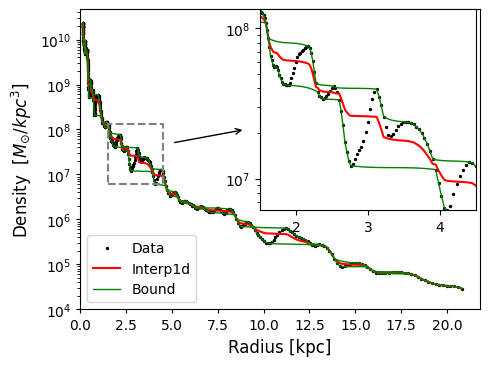

In [14]:
from gal3d.field.spherical_field import MonotonRay
import matplotlib.pyplot as plt

ray = MonotonRay(x,y,is_decreasing=True)



fig = plt.figure(dpi=100,figsize=(4,3))
ax1 = fig.add_axes((0,0,1,1))



ax1.scatter(x,y,s=2,c='k',label='Data')

ax1.plot(x,ray(x),color='r',label="Interp1d")
ax1.plot(x,ray.lower(x),color='g',linewidth = 1, label='Bound')
ax1.plot(x,ray.upper(x),color='g',linewidth = 1)

ax1.legend(loc='lower left')

ax1.set_yscale('log')
ax1.set_xlim(0,x[-1]+1)
ax1.set_ylim(1e4,)

ax2 = fig.add_axes((0.45, 0.33, 0.54, 0.67))

sel = (x>1.5)&(x<4.5)

ax2.scatter(x[sel],y[sel],s=2,c='k')
ax2.plot(x[sel],ray(x[sel]),color='r',label="Interp1d")
ax2.plot(x[sel],ray.lower(x[sel]),color='g',linewidth = 1, label='Bound')
ax2.plot(x[sel],ray.upper(x[sel]),color='g',linewidth = 1)

ax2.set_yscale('log')
ax2.set_xlim(1.5,4.5)
ax2.set_ylim(np.min(y[sel]),np.max(y[sel]))

y1,y2 = ax2.get_ybound()
x1,x2 = ax2.get_xbound()
ax1.plot([x1,x2,x2,x1,x1],[y1,y1,y2,y2,y1],c='grey',linestyle="--")

import matplotlib.patches as mpatches

arrow = mpatches.FancyArrowPatch((5, 5e7), (9, 1e8),
                                 mutation_scale=10,arrowstyle="->")
ax1.add_patch(arrow)

ax1.set_xlabel("Radius [kpc]",fontsize=12)
ax1.set_ylabel(r'Density $\ [M_{\odot}/kpc^3]$',fontsize=12)

ax1.xaxis.set_tick_params()

ax1.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True, labeltop=False,size=3,labelsize=10)
ax1.tick_params(axis='y', size=3,labelsize=10)
plt.show()